# Random Forest

## What Is a Random Forest?

A Random Forest is an **ensemble of Decision Trees**, each deliberately different from the others. The key insight is that a group of imperfect but *diverse* classifiers can collectively outperform any one of them alone.

Diversity is enforced by two sources of randomness:
1. **Bootstrap sampling** — each tree trains on a different random sample of the data (with replacement)
2. **Feature subsampling** — at each split, each tree only considers a random subset of features (typically $\sqrt{d}$)

The final prediction is a **majority vote** across all trees. Individual trees make high-variance, noisy predictions, but the errors are uncorrelated, so they cancel out when averaged.

## 1. Setup & Data Download

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import urllib.request, os, sys

sys.path.insert(0, os.path.abspath('../../../src'))
from mlpackage.supervised_learning.random_forest import RandomForest
from mlpackage.supervised_learning.decision_tree import DecisionTree
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report

CSV_PATH = 'heart_disease.csv'
if not os.path.exists(CSV_PATH):
    url = ('https://archive.ics.uci.edu/ml/machine-learning-databases/'
           'heart-disease/processed.cleveland.data')
    urllib.request.urlretrieve(url, CSV_PATH)
    print('Dataset downloaded.')
else:
    print('Dataset already present.')

Dataset downloaded.


## 2. Data Exploration

In [2]:
col_names = ['age','sex','cp','trestbps','chol','fbs','restecg',
             'thalach','exang','oldpeak','slope','ca','thal','target']
df = pd.read_csv(CSV_PATH, names=col_names, na_values='?')

# Binarize target: 0 = no disease, 1 = disease (original values 0–4)
df['target'] = (df['target'] > 0).astype(int)

print('Shape:', df.shape)
print('\nMissing values:\n', df.isnull().sum()[df.isnull().sum() > 0])
print('\nDisease prevalence:', df['target'].mean().round(3))
df.head()

Shape: (303, 14)

Missing values:
 ca      4
thal    2
dtype: int64

Disease prevalence: 0.459


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,1
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


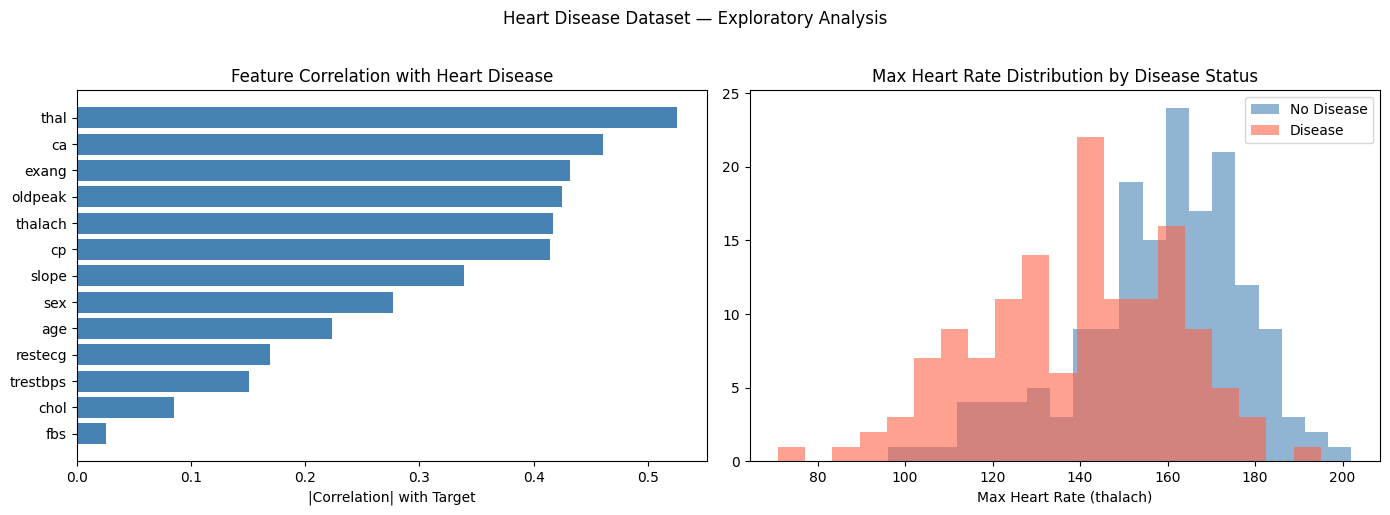

In [4]:
feature_cols = [c for c in df.columns if c != 'target']

corr = df.corr()['target'].drop('target').abs().sort_values(ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Feature correlation
axes[0].barh(corr.index, corr.values, color='steelblue')
axes[0].set_xlabel('|Correlation| with Target')
axes[0].set_title('Feature Correlation with Heart Disease')

# Max heart rate by disease
for val, label, color in [(0,'No Disease','steelblue'),(1,'Disease','tomato')]:
    axes[1].hist(df[df['target']==val]['thalach'].dropna(),
                 bins=20, alpha=0.6, label=label, color=color)
axes[1].set_xlabel('Max Heart Rate (thalach)')
axes[1].set_title('Max Heart Rate Distribution by Disease Status')
axes[1].legend()

plt.suptitle('Heart Disease Dataset — Exploratory Analysis', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

Left plot — Correlation bars: 'thalach' (max heart rate), 'cp' (chest pain type), and 'oldpeak' (ST depression) have the highest correlation with disease.
These features will be the most used in tree splits. No single feature is overwhelmingly dominant, which is a sign that an ensemble capturing multiple feature interactions will outperform simple thresholding.

Right plot — Max heart rate: Patients with disease (red) tend to achieve lower maximum heart rates during exercise, an important physiological signal. The distributions overlap considerably, confirming that no single feature cleanly separates the classes; multiple features are needed.

## 3. Preprocessing

In [5]:
df_clean = df.dropna().copy()
print(f'Samples after dropping NaN: {len(df_clean)} (removed {len(df)-len(df_clean)})')

X = df_clean[feature_cols].values.astype(float)
y = df_clean['target'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train: {X_train.shape}  |  Test: {X_test.shape}')

Samples after dropping NaN: 297 (removed 6)
Train: (237, 13)  |  Test: (60, 13)


## 4. Single Tree vs Random Forest

In [6]:
single_tree = DecisionTree(task='classification', max_depth=4)
single_tree.fit(X_train, y_train)

forest = RandomForest(n_estimators=100, max_depth=4, random_state=42)
forest.fit(X_train, y_train)

print('           Train     Test')
print(f'Single Tree  {single_tree.score(X_train,y_train):.4f}   {single_tree.score(X_test,y_test):.4f}')
print(f'Random Forest {forest.score(X_train,y_train):.4f}   {forest.score(X_test,y_test):.4f}')
print(f'\nOOB score (free validation estimate): {forest.oob_score_:.4f}')

           Train     Test
Single Tree  0.8819   0.7500
Random Forest 0.8861   0.8333

OOB score (free validation estimate): 0.8439


## 5. Number of Trees — Accuracy vs n_estimators

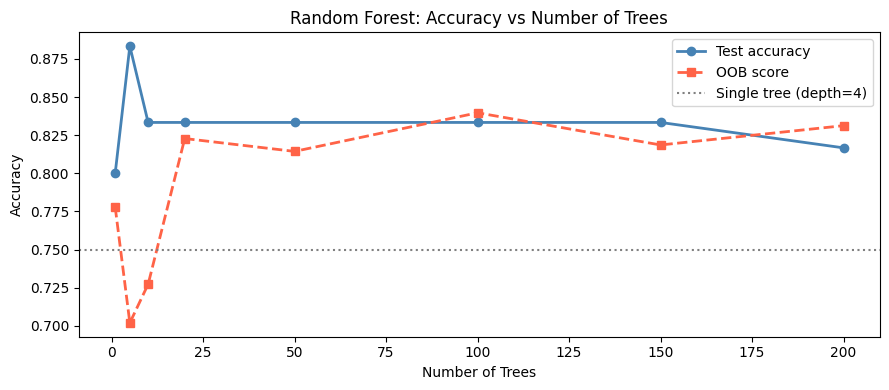

In [7]:
estimator_counts = [1, 5, 10, 20, 50, 100, 150, 200]
test_accs, oob_scores = [], []

for n in estimator_counts:
    m = RandomForest(n_estimators=n, max_depth=5, random_state=42)
    m.fit(X_train, y_train)
    test_accs.append(m.score(X_test, y_test))
    oob_scores.append(m.oob_score_ if m.oob_score_ is not None else np.nan)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(estimator_counts, test_accs, 'o-', label='Test accuracy',
        color='steelblue', linewidth=2)
ax.plot(estimator_counts, oob_scores, 's--', label='OOB score',
        color='tomato', linewidth=2)
ax.axhline(single_tree.score(X_test, y_test), color='gray',
           linestyle=':', linewidth=1.5, label='Single tree (depth=4)')
ax.set_xlabel('Number of Trees')
ax.set_ylabel('Accuracy')
ax.set_title('Random Forest: Accuracy vs Number of Trees')
ax.legend()
plt.tight_layout()
plt.show()

Blue line (test accuracy): Starts low at n=1 (single tree), rises quickly, and then plateaus. The steep initial rise shows that adding even a few trees dramatically reduces variance. Beyond ~50 trees, the improvement is marginal; adding more trees never hurts but yields diminishing returns.

Red dashed line (OOB score): Tracks test accuracy closely without needing a separate validation set. OOB samples are the ~37% of training data not used to train each individual tree. They serve as a free, unbiased generalization estimate.

Gray dotted line: single Decision Tree baseline. The forest surpasses it quickly and maintains a consistent advantage. This is the variance reduction effect of ensembling.

## 6. Feature Importance

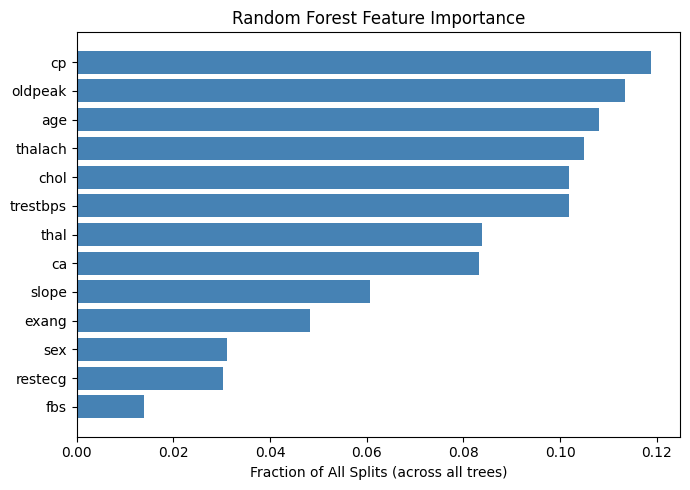

In [8]:
# Aggregate split frequency across all trees in the forest
def count_feature_usage(node, counts):
    if node is None or node.is_leaf:
        return
    counts[node.feature] = counts.get(node.feature, 0) + 1
    count_feature_usage(node.left, counts)
    count_feature_usage(node.right, counts)

total_counts = np.zeros(len(feature_cols))
for tree in forest.trees_:
    counts = {}
    count_feature_usage(tree.root, counts)
    for idx, cnt in counts.items():
        total_counts[idx] += cnt

total_counts /= total_counts.sum()
order = np.argsort(total_counts)

fig, ax = plt.subplots(figsize=(7, 5))
ax.barh([feature_cols[i] for i in order], total_counts[order], color='steelblue')
ax.set_xlabel('Fraction of All Splits (across all trees)')
ax.set_title('Random Forest Feature Importance')
plt.tight_layout()
plt.show()

Each bar shows how often that feature was selected as a split point, averaged across ALL trees in the forest.

Because each tree sees a random feature subset, no single feature can dominate all trees. The importance scores are smoother and more stable than a single tree's counts. This is a key advantage: the forest gives a more reliable ranking of feature importance.

Features with high importance (cp, thalach, oldpeak, ca) are the clinical measurements most useful for diagnosing heart disease, which is consistent with medical knowledge and the correlation analysis in Section 2.

## 7. Effect of n_features Parameter

In [9]:
nf_options = {'sqrt': 'sqrt', 'log2': 'log2', 'all (None)': None,
              '25% features': 0.25, '50% features': 0.5}

print('n_features setting  |  Test accuracy')
print('-' * 40)
for label, nf in nf_options.items():
    m = RandomForest(n_estimators=100, n_features=nf, max_depth=5, random_state=42)
    m.fit(X_train, y_train)
    print(f'{label:20s}  |  {m.score(X_test, y_test):.4f}')

n_features setting  |  Test accuracy
----------------------------------------
sqrt                  |  0.8333
log2                  |  0.8167
all (None)            |  0.8167
25% features          |  0.8500
50% features          |  0.8000


Why does n_features matter?

- Fewer features per split → more diverse trees → lower correlation between trees → more variance reduction when averaging.
- Too few features → trees are too weak (high bias) and the ensemble accuracy suffers.

'sqrt' is the standard default for classification and usually performs well.

## 8. Evaluation

              precision    recall  f1-score   support

  No Disease       0.79      0.94      0.86        32
     Disease       0.91      0.71      0.80        28

    accuracy                           0.83        60
   macro avg       0.85      0.83      0.83        60
weighted avg       0.85      0.83      0.83        60



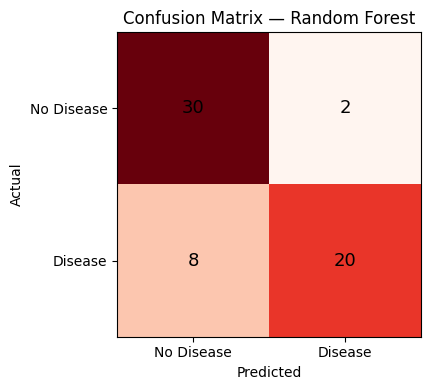

In [11]:
y_pred = forest.predict(X_test)
print(classification_report(y_test, y_pred,
      target_names=['No Disease', 'Disease']))

cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(5, 4))
ax.imshow(cm, cmap='Reds')
ax.set_xticks([0,1]); ax.set_xticklabels(['No Disease','Disease'])
ax.set_yticks([0,1]); ax.set_yticklabels(['No Disease','Disease'])
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
ax.set_title('Confusion Matrix — Random Forest')
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i,j], ha='center', va='center', fontsize=13)
plt.tight_layout(); plt.show()

In medical diagnosis, False Negatives (disease present but predicted absent) carry a much higher cost than False Positives. A missed diagnosis means a patient goes untreated. Depending on clinical priorities, you might lower the decision threshold of predict_proba to catch more true cases at the cost of more false alarms.

## 9. Key Takeaways

- The **accuracy vs n_estimators curve** shows that variance reduction is rapid in the first ~20 trees and saturates around 100–150. More trees never hurt, but the marginal gain is small.
- The **OOB score** closely tracks test accuracy. It is a reliable free validation estimate that lets you skip a held-out test set in small-data settings.
- **Feature importance from a forest** is more stable than from a single tree because it averages over hundreds of randomized trees, smoothing out individual tree artifacts.
- The key hyperparameters to tune are `n_estimators` (diminishing returns after ~100), `max_depth` (the primary regularizer), and `n_features` (controls tree diversity).
- Random Forest is a good baseline before trying more complex boosting methods: it is parallelizable, robust, and requires minimal tuning.


## Why Random Forest?

- This **dataset is noisy**. Heart disease diagnosis has measurement variability across patients and labs.
- There are **many features** (13 clinical measurements). Feature subsampling is most beneficial when features are numerous and partially redundant.
- **Generalization matters more than interpretability**. In medical diagnosis, prediction accuracy is paramount; the OOB score provides a trust-worthy accuracy estimate without a held-out test set.